In [14]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import time
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# 1. Sentence Embeddings

In [2]:
df = pd.read_csv("../data/cleaned/cleaned_review.csv")

In [3]:
model = SentenceTransformer('all-MiniLM-L6-v2')
sample_embedding = model.encode("battery not charging")
print(sample_embedding.shape)
print(sample_embedding[:20])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

(384,)
[ 0.00735132  0.07920277 -0.03673968  0.04877741  0.03757465 -0.05372424
  0.00643621 -0.03428637  0.01368661  0.04400532  0.0360377  -0.08866917
  0.02617384  0.17098951 -0.03690805 -0.02717269 -0.03655374 -0.00205859
  0.01909832  0.01223372]


In [ ]:
start = time.time()
embeddings = model.encode(df["text_clean_full"].tolist(),show_progress_bar=True)
end = time.time()

print(f"Time taken: {(end-start):.2f} seconds")
print(embeddings.shape) 

In [9]:
np.save("../data/cleaned/sentence_embeddings.npy",embeddings)

In [4]:
embeddings = np.load("../data/cleaned/sentence_embeddings.npy")

In [5]:
embeddings.shape

(30157, 384)

# 2. Semantic search function

In [6]:
import re
import emoji
import nltk
from nltk.corpus import stopwords
def text_preprocessing(text,remove_stopwords=False):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+","",text)
    text = re.sub(r'&[a-z]+;|&#\d+;', '', text) 
    text = re.sub(r'<[^>]+>', '', text) 
    text = emoji.replace_emoji(text,replace="")
    special_character_pattern = r'[^a-zA-Z0-9\s]+'
    text = re.sub(special_character_pattern,"",text)
    text = re.sub(r"\s+"," ",text).strip()
    if remove_stopwords:
        stop_words = set(stopwords.words("english"))
        words = text.split(" ")
        words = [word for word in words if word not in stop_words]
        text = " ".join(words)
    
    return text

In [7]:
def search(query,model,embeddings,df,top_k=5):
    query = text_preprocessing(query,remove_stopwords=False)
    query_embedding = model.encode(query).reshape(1,-1) #cosine similarity expects a 2D array
    cos_similarity = cosine_similarity(embeddings,query_embedding).flatten() # to get a 1D array for argsort
    asc_indexes = np.argsort(cos_similarity)
    desc_indexes = asc_indexes[::-1]
    desc_indexes = desc_indexes[:top_k]
    return df.iloc[desc_indexes]

# 3. Testing on 10 handwritten queries (same as TF-IDF)

In [8]:
queries = [
    "Battery not working",
    "Charging wire not working",
    "Screen is broken",
    "Packaging is broken",
    "Bluetooth not working",
    "Broken Case",
    "Incompatible accessory",
    "Bad sound quality",
    "Uncomfortable while wearing",
    "the product is not what it markets itself"
]

for q in queries:
    print(f"Query: {q}")
    results = search(q,model,embeddings,df,top_k=3)
    print(results[['rating','title','text']])

Query: Battery not working
       rating                             title  \
29286     2.0                             Nope.   
29641     1.0  Battery will not hold a CHARGE!.   
10849     2.0                         Two Stars   

                                                    text  
29286                             Battery does not last.  
29641                   Battery will not hold a CHARGE!.  
10849  Battery will not hold a charge and cant be rep...  
Query: Charging wire not working
       rating                               title                         text
8828      1.0  Was not the fastest of fast charge   Electric wire did not work
6404      1.0                      waste of money  wont charge properly at all
10297     1.0                            One Star    Does not charge at all...
Query: Screen is broken
       rating                    title  \
8075      2.0                Two Stars   
28127     1.0                 One Star   
28035     1.0  Was hoping for the

# 4. UMAP visualization

In [9]:
import umap

In [ ]:
reducer = umap.UMAP(n_components=2,random_state=42)
reduced_embeddings = reducer.fit_transform(embeddings)


c:\Users\Vansh\anaconda3\envs\nlp_project\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(30157, 2)

In [12]:
reduced_embeddings.shape

(30157, 2)

In [21]:
reduced_embeddings

array([[ 0.80348086,  1.5861834 ],
       [-0.31705093, -0.7976803 ],
       [ 3.314327  ,  3.370231  ],
       ...,
       [ 3.2048752 ,  2.2896075 ],
       [ 2.4830444 ,  2.2807336 ],
       [ 0.3314477 ,  1.5624148 ]], shape=(30157, 2), dtype=float32)

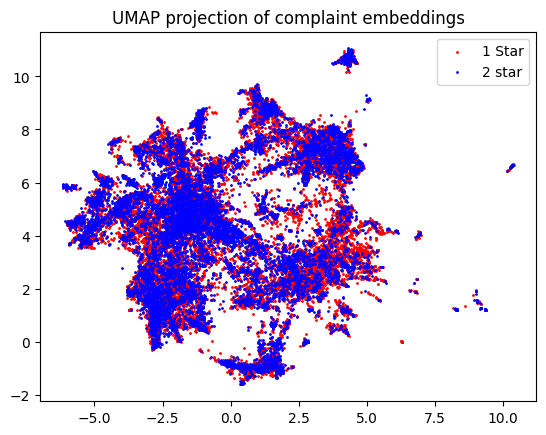

In [31]:
mask_1star = df['rating'] == 1.0
mask_2star = df['rating'] == 2.0
plt.scatter(
    reduced_embeddings[mask_1star,0], # x coordinate of the 1 star review
    reduced_embeddings[mask_1star,1], # y coordinate of the 1 star review
    s = 1,
    c = 'red',
    label = '1 Star'
)
plt.scatter(
    reduced_embeddings[mask_2star,0], # x coordinate of the 2 star review
    reduced_embeddings[mask_2star,1], # y coordinate of the 2 star review
    s = 1,
    c = 'blue',
    label = '2 star'
)
plt.legend()
plt.title("UMAP projection of complaint embeddings")
plt.savefig("../data/plots/Umap_visualization.png",dpi=150,bbox_inches='tight')
plt.show()

In [ ]:
wrong_product_search = search("recieved wrong item",model,embeddings,df,top_k=5)
print(wrong_product_search[['rating','title','text']])

       rating                title  \
28425     1.0    Did not like this   
2866      1.0  RETURNS NOT ALLOWED   
13675     2.0            Two Stars   
18572     1.0                 good   
20381     1.0             One Star   

                                                    text  
28425                                      Returned item  
2866   Make sure you order the correct item because i...  
13675                           Item did not fully work.  
18572                                    i returned item  
20381                            wrong item. Did not fit  


In [30]:
fake_product_search = search("recieved fake product",model,embeddings,df,top_k=5)
print(fake_product_search[['rating','title','text']])

       rating                          title  \
11565     1.0              Fake Fake Fake!!!   
15922     1.0     Does not work with iPhones   
27496     2.0                         Decent   
17867     1.0                          Fraud   
5054      1.0  Caveat emptor! Beware fakes!!   

                                                    text  
11565  Fake Fake Fake!!! This is a knock off and shou...  
15922                The product has false advertisement  
27496  Product was it advertise but it came and a rea...  
17867  I am not sure what product the other reviewers...  
5054   I purchased my Lifeproof case from the company...  


## Semantic Search vs TF-IDF — Head-to-Head Evaluation

Tested both systems on the same 10 queries.

**Semantic search won 9/10 queries** — correctly surfaced complaint-specific results
even when query words didn't literally appear in the reviews (e.g. "screen is broken"
matched "defective screen" and "screen cracked").

**TF-IDF won 1/10 queries** — "incompatible accessory" where the rare, precise
technical word "incompatible" gave TF-IDF a strong exact-match signal that semantic
search over-generalized into broader "not working" results.

**Key insight:** Semantic search captures meaning over vocabulary. TF-IDF captures
rare, distinctive vocabulary precisely. A production system would combine both
(hybrid retrieval) to get the best of both approaches.

**Core limitation of TF-IDF addressed:** "Screen is broken" now correctly matches
"defective screen arrived" and "screen cracked on arrival" — zero shared words,
high semantic similarity. TF-IDF scored these as unrelated.

## UMAP Visualization — Key Findings

- 30,157 complaints projected from 384D to 2D using UMAP
- 1-star and 2-star reviews are thoroughly mixed → confirms both rating
  categories represent similar complaint types, validating our filtering decision
- Main blob represents the broad "product not working" complaint space
- Isolated cluster (top-right) identified as fake/fraud complaints —
  semantically distinct enough from general complaints to form their own region
- Outliers on the right represent highly unique, one-off complaints

**Implication:** Complaint clusters are naturally discoverable from embeddings alone,
without any labels — motivating BERTopic topic modeling in Phase 5.